### Making src/ importable

In [4]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd() / "src"))

In [5]:
from src.matcher import match_jobs, add_overlap_missing, extract_resume_skills

ModuleNotFoundError: No module named 'src'

## Step 1 — Load deduped CSVs from prepared/ and select minimal columns

In [6]:
# STEP 1 — Load & select minimal columns (job_title, job_description, qualifications)

import pandas as pd
%run ./hidden.ipynb

# Inputs (already deduped)
p_mr = datasets_folder_path / "prepared" / "morocco_deduped.csv"
p_dc = datasets_folder_path / "prepared" / "dice_com_deduped.csv"
p_sl = datasets_folder_path / "prepared" / "srilanka_deduped.csv"

# Morocco → ['Job Title','Job Description','Qualifications'] (345)
df_mr = pd.read_csv(p_mr, low_memory=False)
mr_cols = {
    "Job Title": "job_title",
    "Role": "role",
    "Qualifications": "qualifications",
    "skills": "skill_set", 
    "Job Description": "job_description",
     
}
df_mr = df_mr[list(mr_cols.keys())].rename(columns=mr_cols)

# Dice.com → ['jobtitle','jobdescription'] (no qualifications) (20,958)
df_dc = pd.read_csv(p_dc, low_memory=False)
dc_cols = {
    "jobtitle": "job_title",
    "skills": "skill_set",
    "jobdescription": "job_description",   
}
df_dc = df_dc[list(dc_cols.keys())].rename(columns=dc_cols)
df_dc["qualifications"] = pd.NA  # not available

# Sri Lanka → ['Job Title','Job Description','Student Qualification'] (19,831)
df_sl = pd.read_csv(p_sl, low_memory=False)
sl_cols = {
    "Job Title": "job_title",
    "Job Role": "role",
    "Student Qualification": "qualifications",
    "Student Skills": "skill_set",
    "Job Description": "job_description",
    
    
}
df_sl = df_sl[list(sl_cols.keys())].rename(columns=sl_cols)

# Combine to a single minimal frame
df_min = pd.concat([df_mr, df_dc, df_sl], ignore_index=True)

print("Combined minimal shape:", df_min.shape)
print(df_min.sample(3, random_state=7))


Python executable: /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/.venv/bin/python
Enable user-site: False
Datasets folder loaded from project root
Combined minimal shape: (40774, 5)
                                    job_title                  role  \
3059   Sr. Infrastructure/ Framework Engineer                   NaN   
27575           Cloud Infrastructure Engineer       DevOps Engineer   
33974                           iOS Developer  Mobile App Developer   

                   qualifications                               skill_set  \
3059                          NaN  Sr. Infrastructure/ Framework Engineer   
27575  BSc in Information Systems             AWS, CSS, Power BI, Node.js   
33974  BSc in Information Systems          Python, React, SQL, C#, Docker   

                                         job_description  
3059   As an Infrastructure/ Framework Engineer you w...  
27575  Manages deployment pipelines and infrastructur...  
33974  Develops and tests mobi

## Step 2 — Normalize text and add a coarse “field” label from job_title

### Field Keyword Mapping

In [ ]:
import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------------
# Expect this to be defined (from your hidden/config). If not, set it:
# from pathlib import Path
# datasets_folder_path = Path("datasets")

prepared = datasets_folder_path / "prepared"
raw      = datasets_folder_path / "raw"
processed= datasets_folder_path / "processed"
processed.mkdir(parents=True, exist_ok=True)

# Try to use the prepared deduped files if they exist; fall back to raw.
candidates = []
for folder in [prepared, raw]:
    if folder.exists():
        candidates += sorted(folder.glob("*.csv"))
assert candidates, f"No CSV files found under {prepared} or {raw}"

print(f"Found {len(candidates)} CSVs to scan.")

# ------------------------------------------------------------------
# 1) Your FIELD_MAP (paste your expanded version here)
# ------------------------------------------------------------------
FIELD_MAP = {
    "Data": [
        "data ", "bi ", "business intelligence", "etl", "sql ", "power bi", "tableau",
        "data engineer", "data warehouse", "data pipeline"
    ],
    "ML/AI": [
        "machine learning", "ml ", "ai ", "nlp", "deep learning", "computer vision",
        "neural network", "transformer", "llm", "langchain"
    ],
    "Backend": [
        "backend", "back-end", "api", "java ", "spring", "django", "flask", "node",
        "express", "fastapi", "golang", "php", "ruby"
    ],
    "Frontend": [
        "frontend", "front-end", "react", "angular", "vue", "svelte", "ui ", "ux ",
        "typescript", "next.js"
    ],
    "DevOps": [
        "devops", "cloud", "aws", "azure", "gcp", "kubernetes", "docker", "ci/cd",
        "sre", "terraform", "ansible", "jenkins"
    ],
    "Security": [
        "security", "soc", "iam", "infosec", "penetration", "siem", "cybersecurity"
    ],
    "Support/IT": [
        "help desk", "technical support", "system admin", "sysadmin", "it support", "desktop support"
    ],
    "Analytics": [
        "business analyst", "analyst ", "insights", "reporting", "kpi", "metrics", "data analysis"
    ],
    "Mobile": [
        "ios", "android", "mobile", "swift", "kotlin", "react native", "flutter"
    ],
    "Testing": [
        "qa", "tester", "quality assurance", "testing", "selenium", "cypress", "automation"
    ],
    "Engineering": [
        "engineer", "engineering"  # fallback
    ],
    # add your MBA/BCA/MCA buckets here if you want them included
    "Product/Management": [
        "product manager", "product owner", "scrum master", "program manager",
        "agile", "stakeholder", "roadmap"
    ],
    "Marketing/Sales": [
        "marketing", "digital marketing", "seo", "sem", "crm", "sales", "business development"
    ],
}

# ------------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------------
LOWER = lambda s: str(s).strip().lower() if pd.notna(s) else ""

TITLE_CANDIDATES = {
    "job title","job_title","title","position","role_title","jobtitle","designation"
}
ROLE_CANDIDATES = {
    "role","job_role","jobrole","position","designation","function"
}
DESC_CANDIDATES = {
    "job description","job_description","description","jd","details","summary"
}

def pick_col(cols, candidates):
    """Pick the first matching column (case-insensitive) or None."""
    lcols = {c.lower(): c for c in cols}
    for c in candidates:
        if c in lcols:
            return lcols[c]
    return None

def infer_field(text: str) -> str:
    """Infer field using FIELD_MAP by scanning text."""
    t = LOWER(text)
    for field, keys in FIELD_MAP.items():
        for k in keys:
            if k in t:
                return field
    return "Other"

def normalize_role(r: str) -> str:
    """Clean a role/title string into a consistent display value."""
    r = LOWER(r)
    # remove brackets and extra spaces
    r = re.sub(r"\s+", " ", r)
    r = r.strip(" -_/|·•—")
    # title-case but keep common abbreviations
    nice = r.title()
    # fix common bits
    nice = nice.replace("Qa", "QA").replace("Ui", "UI").replace("Ux", "UX").replace("Bi ", "BI ")
    nice = nice.replace("Ml ", "ML ").replace("Ai ", "AI ").replace("Nlp", "NLP")
    return nice

# ------------------------------------------------------------------
# 3) Scan CSVs and collect roles per field
# ------------------------------------------------------------------
field_to_roles = defaultdict(Counter)
rows_scanned = 0

for path in tqdm(candidates, desc="Scanning CSVs"):
    try:
        df = pd.read_csv(path, low_memory=False)
    except Exception as e:
        print(f"Skip {path.name}: {e}")
        continue

    cols = list(df.columns)
    lmap = {c.lower(): c for c in cols}

    tcol = pick_col(cols, TITLE_CANDIDATES)
    rcol = pick_col(cols, ROLE_CANDIDATES)
    dcol = pick_col(cols, DESC_CANDIDATES)

    if not tcol and rcol:
        tcol = rcol
    if not tcol:
        # no usable columns in this file
        continue

    title_series = df[tcol].astype(str)
    role_series  = df[rcol].astype(str) if rcol else None
    desc_series  = df[dcol].astype(str) if dcol else None

    for i in range(len(df)):
        title = title_series.iat[i] if pd.notna(title_series.iat[i]) else ""
        role  = role_series.iat[i]  if role_series is not None and pd.notna(role_series.iat[i]) else ""
        desc  = desc_series.iat[i]  if desc_series is not None and pd.notna(desc_series.iat[i]) else ""

        # choose role if present; else fallback to title
        chosen_role = role if role.strip() else title
        if not chosen_role.strip():
            continue

        # infer field using role+title+desc for more signal
        blob_for_field = f"{chosen_role} | {title} | {desc}"
        field = infer_field(blob_for_field)

        field_to_roles[field][normalize_role(chosen_role)] += 1
        rows_scanned += 1

print(f"\nScanned rows: {rows_scanned:,}")

# ------------------------------------------------------------------
# 4) Build final mapping (top roles per field) and save
# ------------------------------------------------------------------
TOP_K = 60  # adjust as you like
field_role_map = {
    field: [role for role, _cnt in roles.most_common(TOP_K)]
    for field, roles in sorted(field_to_roles.items(), key=lambda kv: (-sum(kv[1].values()), kv[0]))
}

# Small cleanup: drop empty fields
field_role_map = {k: v for k, v in field_role_map.items() if v}

out_path = processed / "field_role_map.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(field_role_map, f, ensure_ascii=False, indent=2)

print(f"✅ Saved field→role map to: processed/field_role_map.json")

# Peek a few fields
for f_name in list(field_role_map.keys())[:6]:
    sample = ", ".join(field_role_map[f_name][:10])
    print(f"- {f_name}: {sample} ...")


Found 10 CSVs to scan.


Scanning CSVs: 100%|██████████| 10/10 [00:08<00:00,  1.25it/s]


Scanned rows: 128,223
✅ Saved field→role map to: processed/field_role_map.json
- Data: Data Visualization Expert, Business Intelligence Analyst, Junior Data Analyst, Data Analyst, Data Scientist, Java Developer, Data Architect, .Net Developer, Business Analyst, Software Engineer ...
- Other: Project Manager, .Net Developer, Technical Writer, Systems Administrator, Web Developer, Software Developer, Front End Developer, Robert Half Technology Account Executive Cs, Senior .Net Developer, Full Stack Developer ...
- Security: Information Security Analyst, Soc Analyst, System Administrator, Infrastructure Support, Network Engineer, Security Engineer, Security Analyst, Network Security Engineer, Robert Half Technology Account Executive Cs, It Security Analyst ...
- Frontend: UI Developer, React Developer, Frontend Developer, Web Designer, UX Designer, UI/UX Designer, Linux Engineer, Linux Administrator, Front-End Developer, Interaction Designer ...
- Analytics: System Analyst, It Business A

### Normalize text + add 'field' (broad category from job_title keywords)

In [ ]:
# STEP 2 — Normalize text + add 'field' (broad category from role/title using role→field map + keywords)

import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
%run ./hidden.ipynb

# ----------------------------
# Paths
# ----------------------------
p_roles_map = datasets_folder_path / "processed" / "field_role_map.json"   # created earlier
assert p_roles_map.exists(), f"Missing {p_roles_map}"

# ----------------------------
# Load Field→Roles map and build ROLE→Field (reverse)
# ----------------------------
field_to_roles = json.loads(p_roles_map.read_text(encoding="utf-8"))

def _norm_key(s: str) -> str:
    """Normalize text for matching (lowercase, collapse spaces, strip punctuationy edges)."""
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)
    s = s.strip(" -_/|·•—")
    return s

ROLE2FIELD = {}
for fld, roles in field_to_roles.items():
    for r in roles:
        ROLE2FIELD[_norm_key(r)] = fld

# ----------------------------
# Keyword fallback map (paste your expanded FIELD_MAP here)
# ----------------------------
p_fieldmap = datasets_folder_path / "prepared" / "field_map.json"
FIELD_MAP = json.loads(p_fieldmap.read_text(encoding="utf-8"))

# Compile keyword fallbacks once (phrase-aware; flexible whitespace)
def _esc_phrase(s: str) -> str:
    return re.escape(s).replace(r"\ ", r"\s+")

FIELD_PATTERNS = {
    fld: re.compile(r"(?:" + "|".join(_esc_phrase(k) for k in keys) + r")", re.I)
    for fld, keys in FIELD_MAP.items()
}

# ----------------------------
# Normalization for text columns
# ----------------------------
def _norm_text(s):
    if pd.isna(s): 
        return pd.NA
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s if s else pd.NA

for c in ["job_title", "role", "qualifications","skill_set", "job_description"]:
    if c in df_min.columns:
        df_min[c] = df_min[c].map(_norm_text)

# ----------------------------
# Inference: role → field (exact), else keywords on the given string
# ----------------------------
def infer_field_from_string(s: str) -> str:
    """Try role/title string against ROLE2FIELD, then FIELD_MAP keywords; else 'Other'."""
    if not isinstance(s, str) or not s:
        return "Other"
    nk = _norm_key(s)
    # 1) exact role→field mapping
    if nk in ROLE2FIELD:
        return ROLE2FIELD[nk]
    # 2) keyword fallback
    for fld, pat in FIELD_PATTERNS.items():
        if pat.search(s):
            return fld
    return "Other"

# ----------------------------
# Vectorized assignment: prefer role if present, else job_title
# ----------------------------
role_series = df_min["role"] if "role" in df_min.columns else pd.Series([pd.NA]*len(df_min), index=df_min.index)
title_series = df_min["job_title"]

df_min["field"] = np.where(
    role_series.notna() & (role_series != ""),
    role_series.map(infer_field_from_string),
    title_series.map(infer_field_from_string)
)

# ----------------------------
# Diagnostics
# ----------------------------
print("Field distribution (top 12):")
print(df_min["field"].value_counts().head(12).to_string())

print("\nNull check (%):")
print((df_min.isna().mean().round(3) * 100))

print("\nSample rows:")
print(df_min.sample(min(10, len(df_min)), random_state=7)[["job_title","role","field"]])
print("\nFirst 5 rows of df_min:")
print(df_min.head(5))


Datasets folder loaded from project root
Field distribution (top 12):
field
ML/AI             8756
Other             5236
Security          4963
Data              3596
Backend           3504
Mobile            2464
Support/IT        2459
Engineering       2060
Infrastructure    1533
Analytics          953
Frontend           819
Testing            674

Null check (%):
job_title           0.0
role               50.5
qualifications     50.5
skill_set           0.1
job_description     0.0
field               0.0
dtype: float64

Sample rows:
                                       job_title                       role  \
3059      Sr. Infrastructure/ Framework Engineer                       <NA>   
27575              Cloud Infrastructure Engineer            DevOps Engineer   
33974                              iOS Developer       Mobile App Developer   
7629          IT Support and Active Directory_CA                       <NA>   
29115                 Technical Support Engineer      IT Suppor

##### Quick sanity check
What this does:
- Picks 20 random rows (so you don’t drown in output).

Shows:
- role (if present)
- job_title (always there)
- which one your logic would use (role if non-empty, else job_title)
- the final inferred field.

In [ ]:
# ----------------------------
# Quick sanity check (after normalization)
# ----------------------------
import numpy as np

SAMPLE_N = 20  # adjust as needed
sample = df_min.sample(SAMPLE_N, random_state=42)

print("\nSanity check on field assignment:")
for i, row in sample.iterrows():
    role = row.get("role", "")
    title = row.get("job_title", "")
    chosen = role if (pd.notna(role) and str(role).strip()) else title
    print(f"- role='{role}' | title='{title}' → used='{chosen}' → field='{row['field']}'")



Sanity check on field assignment:
- role='<NA>' | title='.NET Developer (DFW, TX)' → used='.NET Developer (DFW, TX)' → field='Other'
- role='Web Developer' | title='Web Designer' → used='Web Developer' → field='ML/AI'
- role='<NA>' | title='QA Automation Engineer (Selenium & API Testing)' → used='QA Automation Engineer (Selenium & API Testing)' → field='Backend'
- role='<NA>' | title='BDM - IT Services' → used='BDM - IT Services' → field='Other'
- role='Machine Learning Engineer' | title='NLP Engineer' → used='Machine Learning Engineer' → field='ML/AI'
- role='<NA>' | title='Help Desk Technician Job in Coppell, TX' → used='Help Desk Technician Job in Coppell, TX' → field='Support/IT'
- role='Network Administrator' | title='Network Engineer' → used='Network Administrator' → field='Security'
- role='Network Administrator' | title='System Administrator' → used='Network Administrator' → field='Security'
- role='<NA>' | title='Front End Web Developer with React Experience - New York City' 

## Step 3 — Save jobs_unified.parquet (locked core data for parsing)

In [ ]:
# STEP 3 — Save final unified minimal dataset (parquet)

out_path = datasets_folder_path / "prepared" / "jobs_unified.parquet"
out_path.parent.mkdir(parents=True, exist_ok=True)

# Keep exactly these columns (schema lock)
df_out = df_min[["job_title", "qualifications", "skill_set", "job_description", "field"]].copy()

df_out.to_parquet(out_path, index=False)
print(f"Saved: prepared/jobs_unified.parquet")
print("Rows:", len(df_out))
print("Preview:")
print(df_out.head(5).to_string(index=False))


Saved: prepared/jobs_unified.parquet
Rows: 40774
Preview:
        job_title qualifications                                                                                                                                       skill_set                                                                                                                                                                                                                                 job_description           field
 Account Director            MBA                               Account management Client relations Marketing strategies Campaign optimization Data analysis Communication skills Account Strategists work in advertising or marketing agencies, managing client accounts. They develop strategies to meet client goals, oversee campaign execution, and maintain client satisfaction by providing expert guidance and solutions. Marketing/Sales
 Account Director            MCA                   Business development Sale

### Save to CSV

In [ ]:
import pandas as pd

df = pd.read_parquet(datasets_folder_path / "prepared" /"jobs_unified.parquet")
df.to_csv(datasets_folder_path / "prepared" /"jobs_unified.csv", index=False)
print("Converted to CSV: jobs_unified.csv")
print(df.head(5).to_string(index=False))

Converted to CSV: jobs_unified.csv
        job_title qualifications                                                                                                                                       skill_set                                                                                                                                                                                                                                 job_description           field
 Account Director            MBA                               Account management Client relations Marketing strategies Campaign optimization Data analysis Communication skills Account Strategists work in advertising or marketing agencies, managing client accounts. They develop strategies to meet client goals, oversee campaign execution, and maintain client satisfaction by providing expert guidance and solutions. Marketing/Sales
 Account Director            MCA                   Business development Sales strategy Market analy

## Step 4 — Hybrid skills extractor (ready to run)

### Debug right before Step-4:

In [ ]:
print("PRE Step-4 df_min shape:", df_min.shape)
print(df_min.sample(2, random_state=7))

PRE Step-4 df_min shape: (40774, 6)
                                    job_title             role  \
3059   Sr. Infrastructure/ Framework Engineer             <NA>   
27575           Cloud Infrastructure Engineer  DevOps Engineer   

                   qualifications                               skill_set  \
3059                         <NA>  Sr. Infrastructure/ Framework Engineer   
27575  BSc in Information Systems             AWS, CSS, Power BI, Node.js   

                                         job_description           field  
3059   As an Infrastructure/ Framework Engineer you w...  Infrastructure  
27575  Manages deployment pipelines and infrastructur...         Backend  


### STEP 4 — Hybrid skills extractor (column skills + description skills → union)
1. Inputs (must exist):
  - prepared/jobs_unified.parquet
  - prepared/skills_taxonomy.json
  - prepared/aliases.json  (optional; will default to {})

2. Inputs (nice-to-have; used only to harvest "skills" columns if available):
  - prepared/morocco_deduped.csv
  - prepared/dice_com_deduped.csv
  - prepared/srilanka_deduped.csv

3. Outputs:
  - processed/jobs_unified_with_skills.parquet
  - processed/skills_extraction_audit.csv   (for quick manual review)

#### 0) Imports & sanity

In [ ]:
# 0) Imports & setup
import re, json, math
from itertools import islice
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

BASE = datasets_folder_path / "prepared"
BASE.mkdir(parents=True, exist_ok=True)

p_unified = BASE / "jobs_unified.parquet"  # output from Step 1–3
print("Reading:", p_unified)
dfu = pd.read_parquet(p_unified)

assert {"job_title","job_description","qualifications","field"}.issubset(dfu.columns)
print("dfu shape BEFORE Step-4:", dfu.shape)
print("Sample rows:")
print(dfu.head(5).to_string(index=False))

Reading: /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/prepared/jobs_unified.parquet
dfu shape BEFORE Step-4: (40774, 5)
Sample rows:
        job_title qualifications                                                                                                                                       skill_set                                                                                                                                                                                                                                 job_description           field
 Account Director            MBA                               Account management Client relations Marketing strategies Campaign optimization Data analysis Communication skills Account Strategists work in advertising or marketing agencies, managing client accounts. They develop strategies to meet client goals, oversee campaign execution, and maintain client satisfaction by provid

#### 1) Normalization helpers

In [ ]:
# 1) Normalization helpers
def norm_text(s):
    if pd.isna(s): return pd.NA
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s if s else pd.NA

for c in ["job_title","job_description","qualifications"]:
    dfu[c] = dfu[c].map(norm_text)

def make_key_df(df: pd.DataFrame) -> pd.Series:
    jt = df["job_title"].fillna("").str.lower().str.strip()
    jd = df["job_description"].fillna("").str.lower().str.strip()
    return jt + "||" + jd

dfu["__key__"] = make_key_df(dfu)

#### 2) Load taxonomy + aliases (works with dict or flat list)

In [ ]:
# paths
p_tax   = datasets_folder_path / "prepared" / "skills_taxonomy.json"
p_alias = datasets_folder_path / "prepared" / "aliases.json" 

# load
taxonomy_raw = json.loads(p_tax.read_text(encoding="utf-8"))
aliases_raw  = json.loads(p_alias.read_text(encoding="utf-8")) if p_alias.exists() else {}

# flatten taxonomy -> set of canonical, lowercase skills
if isinstance(taxonomy_raw, dict):
    CANON_SKILLS = { s.strip().lower()
                     for skills in taxonomy_raw.values()
                     for s in skills if str(s).strip() }
else:
    CANON_SKILLS = { str(s).strip().lower()
                     for s in taxonomy_raw if str(s).strip() }

# normalize aliases to single-string mapping (you already converted to Option A)
ALIASES = { str(k).lower(): str(v).lower()
            for k, v in aliases_raw.items() if str(k).strip() and str(v).strip() }

print(f"Loaded {len(CANON_SKILLS)} canonical skills, {len(ALIASES)} aliases.")

Loaded 296 canonical skills, 80 aliases.


#### 3) Skills from columns (prefer unified skill_set / skills; otherwise harvest from sources)

In [ ]:
# 3) Skills from columns (prefer unified `skill_set` / `skills`; otherwise harvest from sources)
import ast
SEP_PATTERN = re.compile(r"[,\|;/]+")

# Toggle: if True, only keep skills that exist in your taxonomy (CANON_SKILLS)
FILTER_TO_TAXONOMY = False   # set to False if you want to inspect raw coverage first

def to_canon(x: str) -> str:
    x = x.strip().lower()
    return ALIASES.get(x, x)

def parse_listish(x):
    """
    Accepts:
      - real lists: ['Python','SQL']
      - stringified lists: "['Python','SQL']"
      - delimited strings: "Python, SQL | AWS"
    Returns a list[str].
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        # Try to parse JSON/python-like lists first
        if s.startswith("[") and s.endswith("]"):
            try:
                val = ast.literal_eval(s)
                if isinstance(val, list):
                    return [str(v) for v in val]
            except Exception:
                pass
        # Fallback to delimiter split
        return [p.strip() for p in SEP_PATTERN.split(s) if p.strip()]
    return []

def normalize_listish(x):
    items = parse_listish(x)
    out = []
    for item in items:
        low = to_canon(item)
        if not low:
            continue
        if FILTER_TO_TAXONOMY:
            if low in CANON_SKILLS:
                out.append(low)
        else:
            out.append(low)
    return sorted(set(out))

# Case A: unified already carries a skills column
col_candidates = [c for c in ["skill_set","skills"] if c in dfu.columns]
if col_candidates:
    colname = col_candidates[0]
    print(f"Using skills from unified column: {colname} | FILTER_TO_TAXONOMY={FILTER_TO_TAXONOMY}")
    dfu["skills_from_col"] = dfu[colname].apply(normalize_listish)

# Case B: harvest from prepared sources if unified has no skills column
else:
    print("No skills column in unified → harvesting from source CSVs.")
    # (keep the rest of the harvesting logic you already have)

    p_mr = BASE / "morocco_deduped.csv"
    p_dc = BASE / "dice_com_deduped.csv"
    p_sl = BASE / "srilanka_deduped.csv"

    def safe_read_csv(path: Path, usecols: list[str]) -> pd.DataFrame:
        if not path.exists(): return pd.DataFrame()
        try:
            head = pd.read_csv(path, nrows=0, low_memory=False)
            keep = [c for c in usecols if c in head.columns]
            if not keep: return pd.DataFrame()
            return pd.read_csv(path, low_memory=False, usecols=keep)
        except Exception:
            return pd.DataFrame()

    mr = safe_read_csv(p_mr, ["Job Title","Job Description","skills"])
    dc = safe_read_csv(p_dc, ["jobtitle","jobdescription","skills"])
    sl = safe_read_csv(p_sl, ["Job Title","Job Description","Student Skills"])

    def standardize(df, mapping):
        if df.empty: return df
        df = df.rename(columns=mapping).copy()
        for c in ["job_title","job_description","skills_col"]:
            if c in df.columns: df[c] = df[c].map(norm_text)
        return df

    mr = standardize(mr, {"Job Title":"job_title","Job Description":"job_description","skills":"skills_col"})
    dc = standardize(dc, {"jobtitle":"job_title","jobdescription":"job_description","skills":"skills_col"})
    sl = standardize(sl, {"Job Title":"job_title","Job Description":"job_description","Student Skills":"skills_col"})

    harvested = pd.concat([d for d in [mr, dc, sl] if not d.empty], ignore_index=True)
    if harvested.empty:
        dfu["skills_from_col"] = [[] for _ in range(len(dfu))]
    else:
        harvested["__key__"] = make_key_df(harvested)
        harvested = harvested[["__key__","skills_col"]]
        dfu = dfu.merge(harvested, on="__key__", how="left")
        dfu["skills_from_col"] = dfu["skills_col"].apply(normalize_listish)
        dfu.drop(columns=["skills_col"], inplace=True, errors="ignore")
    print("Harvested skills from source CSVs.")

Using skills from unified column: skill_set | FILTER_TO_TAXONOMY=False


##### 3.1. Quick sanity checks

In [ ]:
print("Non-empty skills_from_col rows:", int((dfu["skills_from_col"].apply(len) > 0).sum()))
print(dfu[["skill_set"]].head(10))  # confirm what format you have
print(dfu[["skills_from_col"]].head(10))

Non-empty skills_from_col rows: 40732
                                           skill_set
0  Account management Client relations Marketing ...
1  Business development Sales strategy Market ana...
2  Advertising and marketing knowledge Client rel...
3  Key account management Sales strategy developm...
4  Sales strategies and tactics Account managemen...
5  Client relationship management Customer servic...
6  Account management Sales strategy Negotiation ...
7  Financial reporting Accounting software (e.g.,...
8  Forensic accounting Fraud detection Legal know...
9  Tax preparation Tax planning Tax regulations A...
                                     skills_from_col
0  [account management client relations marketing...
1  [business development sales strategy market an...
2  [advertising and marketing knowledge client re...
3  [key account management sales strategy develop...
4  [sales strategies and tactics account manageme...
5  [client relationship management customer servi...
6  [acco

1) Inspect the 42 empties fast
- confirming why those 42 rows are empty

In [ ]:
mask_empty_col = dfu["skills_from_col"].apply(lambda x: not isinstance(x, list) or len(x)==0)
print("Empty skills_from_col rows:", int(mask_empty_col.sum()))

# Peek a few originals from your source column (skill_set)
print(dfu.loc[mask_empty_col, ["job_title","skill_set"]].head(10).to_string(index=False))


Empty skills_from_col rows: 42
                                                             job_title skill_set
                                                    IT Product Manager      None
                                                       Architect, Data      None
                                                 Sr Architect, Systems      None
                                                 Sr Architect, Systems      None
                                                Sr Developer, Software      None
                                                Sr Developer, Software      None
                                                   Developer, Software      None
                                 Principal Architect, Enterprise Cloud      None
                                       Principal Architect, Enterprise      None
Principal Architect,IT Digital Arch-Bellevue/Bothell,Frisco,TX,Atlanta      None


2) Normalize the empties to [] (safe default)

In [ ]:
# Coerce non-list or None-ish to []
def _ensure_list(x):
    return x if isinstance(x, list) else []

dfu["skills_from_col"] = dfu["skills_from_col"].apply(_ensure_list)

2.1 Check if normalization worked

In [ ]:
print(dfu["skills_from_col"].apply(lambda x: isinstance(x, list)).all())
# list the rows that were showing non previously
print("\n Result of normalization: \n", dfu.loc[mask_empty_col, ["job_title","skill_set","skills_from_col"]].head(50).to_string(index=False))

True

 Result of normalization: 
                                                              job_title skill_set skills_from_col
                                                    IT Product Manager      None              []
                                                       Architect, Data      None              []
                                                 Sr Architect, Systems      None              []
                                                 Sr Architect, Systems      None              []
                                                Sr Developer, Software      None              []
                                                Sr Developer, Software      None              []
                                                   Developer, Software      None              []
                                 Principal Architect, Enterprise Cloud      None              []
                                       Principal Architect, Enterprise      None             

#### 4) Fast, batched description extractor (with progress bar)

In [ ]:
# 4) Fast, batched description extractor
def _esc_phrase(s: str) -> str:
    return re.escape(s).replace(r"\ ", r"\s+")

canon_sorted = sorted(CANON_SKILLS, key=lambda x: (-len(x), x))
BATCH = 400
skill_batches = [canon_sorted[i:i+BATCH] for i in range(0, len(canon_sorted), BATCH)]
SKILL_PATS = [
    re.compile(r"\b(?:" + "|".join(_esc_phrase(s) for s in batch) + r")\b", re.I)
    for batch in skill_batches
]

# alias patterns
ALIAS_PATS = {re.compile(rf"\b{_esc_phrase(k)}\b", re.I): v for k, v in ALIASES.items()}

SINGLE_TOKENS = {s for s in CANON_SKILLS if " " not in s}
TOKEN_RE = re.compile(r"\b\w+\b", re.I)

def extract_skills_fast(text: str):
    if not isinstance(text, str) or not text:
        return []
    t = text.lower()
    found = set()

    # single-token exact hits
    words = set(TOKEN_RE.findall(t))
    found |= (words & SINGLE_TOKENS)

    # alias hits
    for pat, val in ALIAS_PATS.items():
        if pat.search(t):
            found.add(val)

    # phrase-aware matches
    for pat in SKILL_PATS:
        for m in pat.findall(t):
            found.add(m.lower())

    return sorted(found)

def iter_chunks(series, size):
    it = iter(series.items())  # yields (idx, value)
    while True:
        batch = list(islice(it, size))
        if not batch:
            return
        yield batch

CHUNK = 5_000  # bump down if RAM is tight

pairs = []
for batch in tqdm(iter_chunks(dfu["job_description"], CHUNK),
                  total=math.ceil(len(dfu)/CHUNK),
                  desc="Skills from descriptions (chunked)"):
    pairs.extend((idx, extract_skills_fast(txt)) for idx, txt in batch)

desc_series = pd.Series({idx: vals for idx, vals in pairs})
dfu["skills_from_desc"] = dfu.index.map(desc_series)
print("Extracted skills from job descriptions.")

Skills from descriptions (chunked):   0%|          | 0/9 [00:00<?, ?it/s]

Extracted skills from job descriptions.


- Sanity Check

In [ ]:
check_col_dfu = dfu[["skills_from_col","skills_from_desc"]].copy()
print("Check col df shape:", check_col_dfu.shape)
print(check_col_dfu.head(5))

Check col df shape: (40774, 2)
                                     skills_from_col          skills_from_desc
0  [account management client relations marketing...  [advertising, marketing]
1  [business development sales strategy market an...    [business development]
2  [advertising and marketing knowledge client re...             [advertising]
3  [key account management sales strategy develop...                        []
4  [sales strategies and tactics account manageme...                   [sales]


#### 5) Union + diagnostics

In [ ]:
# 5) Union + diagnostics
def jaccard(a, b):
    A, B = set(a or []), set(b or [])
    if not A and not B: return 0.0
    if not (A or B):    return 0.0
    return len(A & B) / len(A | B)

dfu["skills_from_col"]  = dfu["skills_from_col"].apply(lambda x: x if isinstance(x, list) else [])
dfu["skills_from_desc"] = dfu["skills_from_desc"].apply(lambda x: x if isinstance(x, list) else [])

dfu["skills_final"] = [
    sorted(set(c) | set(d))
    for c, d in zip(dfu["skills_from_col"], dfu["skills_from_desc"])
]
dfu["n_col"]   = dfu["skills_from_col"].apply(len)
dfu["n_desc"]  = dfu["skills_from_desc"].apply(len)
dfu["n_final"] = dfu["skills_final"].apply(len)

both = (dfu["n_col"]>0) & (dfu["n_desc"]>0)
dfu["jaccard_overlap"] = 0.0
dfu.loc[both, "jaccard_overlap"] = [
    jaccard(c, d) for c, d in zip(dfu.loc[both,"skills_from_col"], dfu.loc[both,"skills_from_desc"])
]

print("Hybrid skills extraction summary:")
print("Rows:", len(dfu))
print("Rows with skills_from_col > 0:", int((dfu['n_col']  > 0).sum()))
print("Rows with skills_from_desc > 0:", int((dfu['n_desc'] > 0).sum()))
print("Median sizes — col/desc/final:",
      int(dfu['n_col'].median()), int(dfu['n_desc'].median()), int(dfu['n_final'].median()))
if both.any():
    print("Mean Jaccard (where both non-empty):",
          round(dfu.loc[both, 'jaccard_overlap'].mean(), 3))
else:
    print("Mean Jaccard: N/A")

Hybrid skills extraction summary:
Rows: 40774
Rows with skills_from_col > 0: 40732
Rows with skills_from_desc > 0: 23864
Median sizes — col/desc/final: 4 2 6
Mean Jaccard (where both non-empty): 0.074


#### 6) Save (compact) and verify

In [ ]:
# 6) Save (compact) and verify
keep_cols = ["job_title","job_description","qualifications","field",
             "skills_from_col","skills_from_desc","skills_final",
             "n_col","n_desc","n_final","jaccard_overlap"]

# Specifying final output folder
BASE_OUT = datasets_folder_path / "final/jobs_skills"
BASE_OUT.mkdir(parents=True, exist_ok=True)

out_parquet = BASE_OUT / "jobs_unified_with_skills.parquet"
dfu[keep_cols].to_parquet(out_parquet, index=False)
print("✅ Saved → jobs_unified_with_skills.parquet at datasets/final/jobs_skills/jobs_unified_with_skills.parquet")

df.to_csv(BASE_OUT / "jobs_unified_with_skills.csv", index=False)
print("✅ Also saved CSV →","datasets/final/jobs_skills/jobs_unified_with_skills.csv")

# (optional) small audit for manual review
audit = dfu.loc[
    ((dfu["n_desc"] - dfu["n_col"]) >= 3) | (dfu["jaccard_overlap"] <= 0.3)
][["job_title","skills_from_col","skills_from_desc","skills_final","jaccard_overlap"]].head(1000)

audit_csv = BASE_OUT / "skills_extraction_audit.csv"
audit.to_csv(audit_csv, index=False)
print("Audit sample → skills_extraction_audit.csv at datasets/final/jobs_skills/skills_extraction_audit.csv")

✅ Saved → jobs_unified_with_skills.parquet at datasets/final/jobs_skills/jobs_unified_with_skills.parquet
✅ Also saved CSV → datasets/final/jobs_skills/jobs_unified_with_skills.csv
Audit sample → skills_extraction_audit.csv at datasets/final/jobs_skills/skills_extraction_audit.csv


## STEP 5 - Build vocab + job vectors

#### Prerequisites 
Input required: prepared/jobs_unified_with_skills.parquet (saved in Step 4).
- Taxonomy/aliases again for Step 5 not needed.

Outputs we’ll create:
- prepared/skills_vocab.csv
- prepared/jobs_vectors.npz
- prepared/jobs_clean.parquet


### 5.1 — Build vocabulary (SUBSET mode) with path + safe parsing

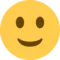 
### Uncomment the commented code if you wanna get into 0 vocab hell :-)

#### Cell 1 — Diagnose + (re)build skills_final if needed

In [ ]:
# # === Step 5.0 — Diagnose & reconstruct skills_final (if needed) ===
# import pandas as pd, ast, re
# from pathlib import Path

# P = datasets_folder_path / "final" / "jobs_skills"
# p_parquet = P / "jobs_unified_with_skills.parquet"
# df = pd.read_parquet(p_parquet)
# print("Loaded:", p_parquet, "| shape:", df.shape)
# print("Columns:", df.columns.tolist())
# print("\nDtypes:\n", df.dtypes)

# # --- helpers ---
# SEP = re.compile(r"[,\|;/•]+")
# def ensure_list(x):
#     """Return a list[str] from possible formats: list, stringified list, delimited string, else []."""
#     if isinstance(x, list):
#         return [str(v).strip().lower() for v in x if str(v).strip()]
#     if isinstance(x, (bytes, bytearray)):
#         x = x.decode("utf-8", errors="ignore")
#     if isinstance(x, str):
#         s = x.strip()
#         # stringified python/json-like list?
#         if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
#             try:
#                 val = ast.literal_eval(s)
#                 if isinstance(val, (list, tuple)):
#                     return [str(v).strip().lower() for v in val if str(v).strip()]
#             except Exception:
#                 pass
#         # otherwise split by common delimiters
#         return [t.strip().lower() for t in SEP.split(s) if t.strip()]
#     return []

# def is_nonempty_listlike(col):
#     """How many rows are non-empty after parsing?"""
#     parsed = col.apply(ensure_list)
#     return int((parsed.apply(len) > 0).sum()), parsed

# # --- find skill columns available ---
# cands = {
#     "skills_final": "skills_final",
#     "skills_from_col": "skills_from_col",
#     "skills_from_desc": "skills_from_desc",
#     "skill_set": "skill_set",
#     "skills": "skills"
# }
# present = [name for name in cands.values() if name in df.columns]
# print("\nSkill-ish columns present:", present)

# # --- try skills_final first ---
# use_col = None
# if "skills_final" in df.columns:
#     nonempty_count, parsed_final = is_nonempty_listlike(df["skills_final"])
#     print("Non-empty after parsing skills_final:", nonempty_count)
#     if nonempty_count > 0:
#         df["skills_final"] = parsed_final
#         use_col = "skills_final"

# # --- else try to reconstruct from from_col / from_desc ---
# if use_col is None and {"skills_from_col","skills_from_desc"}.issubset(df.columns):
#     cnt_col, parsed_col = is_nonempty_listlike(df["skills_from_col"])
#     cnt_desc, parsed_desc = is_nonempty_listlike(df["skills_from_desc"])
#     print("Non-empty after parsing skills_from_col:", cnt_col)
#     print("Non-empty after parsing skills_from_desc:", cnt_desc)
#     # union
#     df["skills_final"] = [
#         sorted(set(parsed_col.iloc[i]) | set(parsed_desc.iloc[i]))
#         for i in range(len(df))
#     ]
#     use_col = "reconstructed(col∪desc)"

# # --- else fall back to skill_set / skills ---
# if use_col is None:
#     for fallback in ["skill_set", "skills"]:
#         if fallback in df.columns:
#             cnt_fb, parsed_fb = is_nonempty_listlike(df[fallback])
#             print(f"Non-empty after parsing {fallback}:", cnt_fb)
#             if cnt_fb > 0:
#                 df["skills_final"] = parsed_fb
#                 use_col = fallback
#                 break

# if use_col is None:
#     raise RuntimeError("No usable skills column found or parsed. Inspect your parquet contents.")

# # --- final sanity + preview ---
# df["skills_final"] = df["skills_final"].apply(lambda x: x if isinstance(x, list) else [])
# nonempty = int((df["skills_final"].apply(len) > 0).sum())
# print(f"\nUsing '{use_col}' → non-empty skills_final rows: {nonempty}/{len(df)}")
# print("\nSample parsed rows:")
# print(df.loc[df["skills_final"].apply(len)>0, ["job_title","skills_final"]].head(5).to_string(index=False))

# # (optional) keep a temp copy in memory; if you want to persist recon to disk, uncomment:
# df.to_parquet(P / "jobs_unified_with_skills_FIXED.parquet", index=False)


#### Cell 2 — Build vocab (Step 5.1) with subset support

In [ ]:
# # 5.1 — Build vocab (subset-safe with safe parsing)
# import pandas as pd, ast
# from collections import Counter

# # p = datasets_folder_path / "final" / "jobs_skills" / "jobs_unified_with_skills.parquet"
# p = datasets_folder_path / "final/jobs_skills/jobs_unified_with_skills.parquet"  
# df = pd.read_parquet(p)

# # --- SUBSET MODE ---
# SUBSET_ROWS = 15000   # set to None for full run
# if SUBSET_ROWS:
#     df = df.head(SUBSET_ROWS).copy()
#     print(f"[Subset mode] Using {len(df)} rows")

# # ensure lists
# def ensure_list(x):
#     if isinstance(x, list):
#         return x
#     if isinstance(x, str):
#         try:
#             val = ast.literal_eval(x)
#             if isinstance(val, list):
#                 return [str(v).lower().strip() for v in val]
#         except Exception:
#             return [s.strip().lower() for s in x.split(",") if s.strip()]
#     return []

# df["skills_final"] = df["skills_final"].apply(ensure_list)

# # build vocab
# freq = Counter([s for row in df["skills_final"] for s in row])
# FREQ_FLOOR = 5
# vocab = sorted([s for s, c in freq.items() if c >= FREQ_FLOOR])

# # specifying folder
# v_folder = datasets_folder_path / "final/jobs_skills/vocab"
# v_folder.mkdir(parents=True, exist_ok=True)

# #saving vocab
# vocab_path = v_folder / "skills_vocab.csv"
# pd.Series(vocab).to_csv(vocab_path, index=False, header=False)

# print("✅ Vocab size:", len(vocab))
# print("Vocab size:", len(vocab), "→", "v_folder/skills_vocab.csv")

### 5.0 — Deep-diagnose and rebuild skills_final (robust parser)

- Handles: real lists, stringified lists (with single/double quotes), doubly-quoted JSON like "['python','sql']", bytes, and plain delimited strings.
- Reconstructs skills_final if needed from skills_from_col ∪ skills_from_desc.

In [ ]:
# # === Step 5.0 — Diagnose & robustly rebuild skills_final (if needed) ===
# import pandas as pd, ast, json, re
# from pathlib import Path

# P = datasets_folder_path / "final" / "jobs_skills"
# p_parquet = P / "jobs_unified_with_skills.parquet"
# df = pd.read_parquet(p_parquet)
# print("Loaded:", p_parquet, "| shape:", df.shape)
# print("Columns:", df.columns.tolist())

# # --- robust list parser ---
# SEP = re.compile(r"[,\|;/•\n\r\t]+")

# def parse_any_list(x):
#     """Return list[str] from list / tuple / set / bytes / stringified list / JSON / delimited string."""
#     # already list-like
#     if isinstance(x, (list, tuple, set)):
#         return [str(v).strip().lower() for v in x if str(v).strip()]
#     # bytes -> str
#     if isinstance(x, (bytes, bytearray)):
#         x = x.decode("utf-8", errors="ignore")
#     # string-like
#     if isinstance(x, str):
#         s = x.strip()
#         if not s or s.upper() in {"N/A", "NONE", "NULL"}:
#             return []
#         # try direct JSON (e.g., ["python","sql"])
#         try:
#             val = json.loads(s)
#             if isinstance(val, (list, tuple)):
#                 return [str(v).strip().lower() for v in val if str(v).strip()]
#         except Exception:
#             pass
#         # sometimes it's doubly quoted JSON: "\"['python','sql']\""
#         if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
#             inner = s[1:-1]
#             # try json on the inner
#             try:
#                 val = json.loads(inner)
#                 if isinstance(val, (list, tuple)):
#                     return [str(v).strip().lower() for v in val if str(v).strip()]
#             except Exception:
#                 # try ast on inner
#                 try:
#                     val = ast.literal_eval(inner)
#                     if isinstance(val, (list, tuple)):
#                         return [str(v).strip().lower() for v in val if str(v).strip()]
#                 except Exception:
#                     pass
#         # try python literal list (e.g., "['python','sql']")
#         if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
#             try:
#                 val = ast.literal_eval(s)
#                 if isinstance(val, (list, tuple)):
#                     return [str(v).strip().lower() for v in val if str(v).strip()]
#             except Exception:
#                 pass
#         # fallback: split by common delimiters
#         return [t.strip().lower() for t in SEP.split(s) if t.strip()]
#     # anything else -> empty
#     return []

# def nonempty_count(series):
#     return int(series.apply(lambda v: len(parse_any_list(v))>0).sum())

# present = [c for c in ["skills_final","skills_from_col","skills_from_desc","skill_set","skills"] if c in df.columns]
# print("Skill-ish columns present:", present)

# # Try to use skills_final if it parses
# use_col = None
# if "skills_final" in df.columns:
#     cnt = nonempty_count(df["skills_final"])
#     print("Non-empty after robust parse skills_final:", cnt)
#     if cnt > 0:
#         use_col = "skills_final"

# # Else reconstruct from col ∪ desc
# if use_col is None and {"skills_from_col","skills_from_desc"}.issubset(df.columns):
#     cnt_col  = nonempty_count(df["skills_from_col"])
#     cnt_desc = nonempty_count(df["skills_from_desc"])
#     print("Non-empty after robust parse skills_from_col:",  cnt_col)
#     print("Non-empty after robust parse skills_from_desc:", cnt_desc)
#     parsed_col  = df["skills_from_col"].apply(parse_any_list)
#     parsed_desc = df["skills_from_desc"].apply(parse_any_list)
#     df["skills_final"] = [sorted(set(a)|set(b)) for a,b in zip(parsed_col, parsed_desc)]
#     use_col = "reconstructed(col∪desc)"

# # Else fall back to skill_set/skills
# if use_col is None:
#     for fb in ["skill_set","skills"]:
#         if fb in df.columns:
#             cnt_fb = nonempty_count(df[fb])
#             print(f"Non-empty after robust parse {fb}:", cnt_fb)
#             if cnt_fb > 0:
#                 df["skills_final"] = df[fb].apply(parse_any_list)
#                 use_col = f"from {fb}"
#                 break

# if use_col is None:
#     raise RuntimeError("No usable skills column could be parsed. Inspect a raw cell to see its actual format.")

# # Final cleanup to ensure list objects
# df["skills_final"] = df["skills_final"].apply(lambda x: x if isinstance(x, list) else parse_any_list(x))
# nonempty = int((df["skills_final"].apply(len) > 0).sum())
# print(f"\nUSING → {use_col}; non-empty skills_final rows: {nonempty}/{len(df)}")
# print(df.loc[df["skills_final"].apply(len)>0, ["job_title","skills_final"]].head(5).to_string(index=False))

# # (Optional) persist a fixed copy so downstream is simple
# fixed_path = P / "vocab" / "jobs_unified_with_skills_FIXED.parquet"
# df.to_parquet(fixed_path, index=False)
# print("Saved fixed parquet →", fixed_path)


#### A) Inspect what’s really in the columns (raw, with repr)
What we’re looking for:

Are they Python lists (e.g., ['python','sql'])?
JSON strings ("["python","sql"]")?
Doubly-quoted strings, bytes, or something exotic?

In [ ]:
# import pandas as pd
# from pathlib import Path

# P = datasets_folder_path / "final" / "jobs_skills"
# p = P / "jobs_unified_with_skills.parquet"
# df = pd.read_parquet(p)
# print("Shape:", df.shape)

# # 1) Types + a few raw examples (repr) from rows that *should* be non-empty
# def show_samples(col_name, count_col, k=5):
#     print(f"\n-- {col_name} (first {k} rows where {count_col}>0) --")
#     idx = df.index[df[count_col] > 0].tolist()[:k]
#     if not idx:
#         print(f"(no rows with {count_col}>0)")
#         return
#     s = df.loc[idx, col_name]
#     for i, val in zip(idx, s):
#         print(f"row {i} type={type(val).__name__} repr={repr(val)[:200]}")

# show_samples("skills_from_col",  "n_col",  k=5)
# show_samples("skills_from_desc", "n_desc", k=5)
# show_samples("skills_final",     "n_final",k=5)

#### B) Ultra-robust parser + rebuild (handles weird encodings)

This will rebuild skills_final from whichever of the three columns has content, using a parser that cracks JSON, Python-literals, double-quoted blobs, and finally falls back to tokenization.

In [ ]:
# import ast, json, re

# TOKEN = re.compile(r"[A-Za-z][A-Za-z0-9\+\.\#/\-]{1,}")
# DELIMS = re.compile(r"[,\|;/•\n\r\t]+")

# def parse_any_list(x):
#     """Return list[str] from list/tuple/set, JSON, python literal, double-quoted inner, or delimited text."""
#     # already list-like
#     if isinstance(x, (list, tuple, set)):
#         return [str(v).strip().lower() for v in x if str(v).strip()]
#     # bytes to str
#     if isinstance(x, (bytes, bytearray)):
#         x = x.decode("utf-8", errors="ignore")
#     # strings
#     if isinstance(x, str):
#         s = x.strip()
#         if not s or s.upper() in {"N/A","NONE","NULL","[]","[ ]"}:
#             return []
#         # JSON first
#         try:
#             val = json.loads(s)
#             if isinstance(val, (list, tuple)):
#                 return [str(v).strip().lower() for v in val if str(v).strip()]
#         except Exception:
#             pass
#         # double-quoted inner
#         if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
#             inner = s[1:-1]
#             # try json on inner
#             try:
#                 val = json.loads(inner)
#                 if isinstance(val, (list, tuple)):
#                     return [str(v).strip().lower() for v in val if str(v).strip()]
#             except Exception:
#                 # try python literal on inner
#                 try:
#                     val = ast.literal_eval(inner)
#                     if isinstance(val, (list, tuple)):
#                         return [str(v).strip().lower() for v in val if str(v).strip()]
#                 except Exception:
#                     pass
#         # python literal list "(...)" or "[...]"
#         if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
#             try:
#                 val = ast.literal_eval(s)
#                 if isinstance(val, (list, tuple)):
#                     return [str(v).strip().lower() for v in val if str(v).strip()]
#             except Exception:
#                 pass
#         # fallback #1: split by delims, keep phrases that look like skills
#         parts = [t.strip() for t in DELIMS.split(s) if t.strip()]
#         if parts:
#             return [p.lower() for p in parts]
#         # fallback #2: token sweep (last resort)
#         return [m.group(0).lower() for m in TOKEN.finditer(s)]
#     # anything else
#     return []

# def ensure_list(col):
#     return col.apply(lambda v: parse_any_list(v))

# # Parse each candidate column independently
# have_cols = [c for c in ["skills_final","skills_from_col","skills_from_desc"] if c in df.columns]
# parsed = {}
# for c in have_cols:
#     parsed[c] = ensure_list(df[c])
#     print(f"parsed non-empty {c}:", int((parsed[c].apply(len)>0).sum()))

# # Rebuild union: prefer existing 'skills_final' if it has content; else union(col, desc)
# if "skills_final" in parsed and (parsed["skills_final"].apply(len)>0).any():
#     df["skills_final"] = parsed["skills_final"]
# else:
#     col = parsed.get("skills_from_col", pd.Series([[]]*len(df), index=df.index))
#     desc = parsed.get("skills_from_desc", pd.Series([[]]*len(df), index=df.index))
#     df["skills_final"] = [sorted(set(a)|set(b)) for a,b in zip(col, desc)]

# # Final sanity + save fixed parquet (note: new path)
# nonempty = int((df["skills_final"].apply(len)>0).sum())
# print(f"\nRebuilt skills_final → non-empty rows: {nonempty}/{len(df)}")

# fixed_path = P / "vocab/jobs_unified_with_skills_FIXED.parquet"
# fixed_path.parent.mkdir(parents=True, exist_ok=True)
# df.to_parquet(fixed_path, index=False)
# print("Saved fixed parquet →", "jobs_unified_with_skills_FIXED.parquet")


#### C) Build vocab on the fixed parquet (subset-safe)

In [ ]:
# # Build vocab from the FIXED parquet
# from collections import Counter

# fixed_path = datasets_folder_path / "final" / "jobs_skills" / "vocab" / "jobs_unified_with_skills_FIXED.parquet"
# df2 = pd.read_parquet(fixed_path)

# # optional subset to unblock
# SUBSET_ROWS = 15000
# if SUBSET_ROWS:
#     df2 = df2.head(SUBSET_ROWS).copy()
#     print(f"[Subset mode] Using {len(df2)} rows")

# df2["skills_final"] = df2["skills_final"].apply(lambda x: x if isinstance(x, list) else [])

# freq = Counter([s for row in df2["skills_final"] for s in row])
# FREQ_FLOOR = 5
# vocab = sorted([s for s,c in freq.items() if c >= FREQ_FLOOR])

# out_csv = datasets_folder_path / "final" / "jobs_skills" / "vocab" / "skills_vocab.csv"
# pd.Series(vocab).to_csv(out_csv, index=False, header=False)
# print("✅ Vocab size:", len(vocab), "→", out_csv)
# print("Top 10:", sorted(freq.items(), key=lambda x: -x[1])[:10])


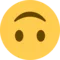
### Here's the right code for a proper vocab

### 5.0 — Repair skills columns (handle ndarray + extract via taxonomy), rebuild skills_final, save FIXED parquet

In [ ]:
# === 5.0 — Repair skills columns (ndarray-aware) + taxonomy-based extraction; rebuild skills_final ===
import re, json, numpy as np, pandas as pd
from pathlib import Path

# Paths
P = datasets_folder_path / "final" / "jobs_skills"
p_in = P / "jobs_unified_with_skills.parquet"
df = pd.read_parquet(p_in)
print("Loaded:", p_in, "| shape:", df.shape)

# -- Load taxonomy / aliases (try final first, fallback to prepared) --
def _read_json_safe(path_list):
    for p in path_list:
        if p.exists():
            return json.loads(p.read_text(encoding="utf-8"))
    return {}

tax_candidates   = [P / "skills_taxonomy.json", datasets_folder_path / "prepared" / "skills_taxonomy.json"]
alias_candidates = [P / "aliases.json",         datasets_folder_path / "prepared" / "aliases.json"]

taxonomy_raw = _read_json_safe(tax_candidates)
aliases_raw  = _read_json_safe(alias_candidates)

# Canonical skills set (dict OR list supported)
if isinstance(taxonomy_raw, dict):
    CANON = {
        str(s).strip().lower()
        for group in taxonomy_raw.values()
        for s in group if str(s).strip()
    }
else:
    CANON = {str(s).strip().lower() for s in (taxonomy_raw or []) if str(s).strip()}
ALIASES = {str(k).lower(): str(v).lower() for k, v in (aliases_raw or {}).items()}

print(f"Loaded taxonomy: {len(CANON)} skills | aliases: {len(ALIASES)}")

# -- Build a single regex that matches any canonical term with safe boundaries --
def _esc_phrase(s: str) -> str:
    return re.escape(s).replace(r"\ ", r"\s+")

canon_sorted = sorted(CANON, key=lambda x: (-len(x), x))  # longer first
if canon_sorted:
    TAX_RE = re.compile(r"\b(?:" + "|".join(_esc_phrase(s) for s in canon_sorted) + r")\b", re.I)
else:
    # empty taxonomy? fall back to no-op matcher
    TAX_RE = re.compile(r"$a")  # never matches

def to_canon(x: str) -> str:
    x = x.strip().lower()
    return ALIASES.get(x, x)

def extract_from_text(text: str):
    """Taxonomy/alias-based extraction from any blob of text."""
    if not isinstance(text, str) or not text.strip():
        return []
    hits = TAX_RE.findall(text)
    return sorted({to_canon(h) for h in hits if h})

def arrayish_to_text(x):
    """Turn numpy arrays / lists / strings into a single text blob for extraction."""
    if isinstance(x, np.ndarray):
        # Flatten and join
        try:
            flat = x.ravel().tolist()
        except Exception:
            flat = list(x)
        return " ".join(str(t) for t in flat if str(t).strip())
    if isinstance(x, (list, tuple, set)):
        return " ".join(str(t) for t in x if str(t).strip())
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8", errors="ignore")
    return str(x) if isinstance(x, str) else ""

# Ensure the three columns exist for downstream logic
for col in ["skills_from_col","skills_from_desc","skills_final"]:
    if col not in df.columns:
        df[col] = None

# Rebuild parsed lists from each source independently, using taxonomy extraction
parsed_col  = df["skills_from_col" ].apply(lambda v: extract_from_text(arrayish_to_text(v)))
parsed_desc = df["skills_from_desc"].apply(lambda v: extract_from_text(arrayish_to_text(v)))
parsed_fin  = df["skills_final"    ].apply(lambda v: extract_from_text(arrayish_to_text(v)))

# Prefer existing skills_final if it had content; else union(col, desc)
has_fin  = (parsed_fin.apply(len)  > 0).sum()
has_col  = (parsed_col.apply(len)  > 0).sum()
has_desc = (parsed_desc.apply(len) > 0).sum()
print(f"Non-empty parsed → final:{has_fin} | col:{has_col} | desc:{has_desc}")

if has_fin > 0:
    df["skills_final"] = parsed_fin
else:
    df["skills_final"] = [sorted(set(a) | set(b)) for a, b in zip(parsed_col, parsed_desc)]

# Final sanity
nonempty = int((df["skills_final"].apply(len) > 0).sum())
print(f"Rebuilt skills_final → non-empty rows: {nonempty}/{len(df)}")
print(df.loc[df["skills_final"].apply(len)>0, ["job_title","skills_final"]].head(5).to_string(index=False))

# Save fixed parquet for Step 5.1+
p_fixed = P / "vocab" / "jobs_unified_with_skills_FIXED.parquet"
p_fixed.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(p_fixed, index=False)
print("✅ Saved FIXED parquet →", p_fixed)


Loaded: /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/jobs_skills/jobs_unified_with_skills.parquet | shape: (40774, 11)
Loaded taxonomy: 296 skills | aliases: 80
Non-empty parsed → final:39808 | col:32303 | desc:23786
Rebuilt skills_final → non-empty rows: 39808/40774
        job_title                                                             skills_final
 Account Director              [account management, advertising, communication, marketing]
 Account Director [business development, leadership, presentation skills, sales, strategy]
Account Executive                                                 [advertising, marketing]
Account Executive                       [account management, negotiation, sales, strategy]
Account Executive                                 [account management, forecasting, sales]
✅ Saved FIXED parquet → /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/j

### 5.1 — Build vocab on the FIXED parquet (subset-safe)

In [9]:
# 5.1 — Build vocab (handles ndarray/list/tuple/set/strings)
import pandas as pd, numpy as np, ast, re
from collections import Counter
from pathlib import Path

P = datasets_folder_path / "final" / "jobs_skills" / "vocab"
p_fixed = P / "jobs_unified_with_skills_FIXED.parquet"
df = pd.read_parquet(p_fixed)
print("Loaded:", p_fixed, "| shape:", df.shape)

# --- subset to move fast ---
SUBSET_ROWS = 15000   # set to None for full run
if SUBSET_ROWS:
    df = df.head(SUBSET_ROWS).copy()
    print(f"[Subset mode] Using {len(df)} rows")

# --- robust list coercion (accept ndarray/list/tuple/set/str) ---
DELIMS = re.compile(r"[,\|;/•\n\r\t]+")

def ensure_list_any(x):
    # ndarray / list-like
    if isinstance(x, (np.ndarray, list, tuple, set)):
        try:
            it = x.ravel().tolist() if isinstance(x, np.ndarray) else list(x)
        except Exception:
            it = list(x)
        return [str(v).strip().lower() for v in it if str(v).strip()]
    # bytes -> str
    if isinstance(x, (bytes, bytearray)):
        x = x.decode("utf-8", errors="ignore")
    # strings: try python-literal, else split
    if isinstance(x, str):
        s = x.strip()
        if not s or s.upper() in {"N/A","NONE","NULL"}:
            return []
        # try python/json-like list first
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            try:
                val = ast.literal_eval(s)
                if isinstance(val, (list, tuple, set)):
                    return [str(v).strip().lower() for v in val if str(v).strip()]
            except Exception:
                pass
        # fallback: split by common delimiters
        return [t.strip().lower() for t in DELIMS.split(s) if t.strip()]
    # anything else
    return []

# coerce column
df["skills_final"] = df["skills_final"].apply(ensure_list_any)

# quick sanity
nonempty = int((df["skills_final"].apply(len) > 0).sum())
print("Non-empty skills_final rows:", nonempty, "/", len(df))
if nonempty == 0:
    # show a couple raw types so we can debug if needed
    sample = df["skills_final"].head(3).tolist()
    print("DEBUG sample skills_final:", sample)

# build vocab
freq = Counter([s for row in df["skills_final"] for s in row])
FREQ_FLOOR = 5  # raise to 8–10 if vocab too large
vocab = sorted([s for s, c in freq.items() if c >= FREQ_FLOOR])

out_csv = P / "skills_vocab.csv"
pd.Series(vocab).to_csv(out_csv, index=False, header=["skills"])

print("✅ Vocab size:", len(vocab))
print("Saved →", out_csv)
# print("Top 10 terms:", sorted(freq.items(), key=lambda x: -x[1])[:10])
print("Top 30 terms:", sorted(freq.items(), key=lambda x: -x[1])[:30])


Loaded: /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/jobs_skills/vocab/jobs_unified_with_skills_FIXED.parquet | shape: (40774, 11)
[Subset mode] Using 15000 rows
Non-empty skills_final rows: 14289 / 15000
✅ Vocab size: 232
Saved → /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/jobs_skills/vocab/skills_vocab.csv
Top 30 terms: [('communication', 6209), ('sql', 3863), ('java', 3329), ('agile', 2697), ('javascript', 2408), ('operations', 2370), ('training', 2289), ('leadership', 2098), ('consulting', 2068), ('linux', 2046), ('oracledb', 2013), ('project management', 1995), ('problem solving', 1747), ('compliance', 1506), ('html', 1427), ('strategy', 1412), ('python', 1362), ('css', 1237), ('sales', 1171), ('collaboration', 1056), ('scrum', 980), ('marketing', 961), ('aws', 926), ('jquery', 911), ('medical', 904), ('healthcare', 800), ('finance', 787), ('shell', 746), ('git', 73

### 5.2 — Vectorize jobs (aligned to the same subset)

In [ ]:
# 5.2 — Vectorize jobs (aligned to the same subset frame 'df')
import numpy as np
from scipy.sparse import csr_matrix, save_npz

vocab = pd.read_csv(P / "skills_vocab.csv", header=None)[0].tolist()
skill_index = {s:i for i,s in enumerate(vocab)}

rows, cols, data = [], [], []
for r, skills in enumerate(df["skills_final"]):
    for s in skills:
        j = skill_index.get(s)
        if j is not None:
            rows.append(r); cols.append(j); data.append(1)

X = csr_matrix((data, (rows, cols)), shape=(len(df), len(vocab)), dtype=np.uint8)

# save artifacts next to FIXED parquet
save_npz(P / "jobs_vectors.npz", X)

keep_cols = ["job_title","job_description","qualifications","field","skills_final"]
df.reset_index(drop=True)[keep_cols].to_parquet(P / "jobs_clean.parquet", index=False)

print("✅ Saved:")
print(" -", P / "jobs_vectors.npz")
print(" -", P / "jobs_clean.parquet")
print("Matrix shape:", X.shape)

✅ Saved:
 - /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/jobs_skills/vocab/jobs_vectors.npz
 - /media/artir/Data1/coding/projects/Final/GitHub/AI-ML_Projects/Capstone-Job-Recommender/datasets/final/jobs_skills/vocab/jobs_clean.parquet
Matrix shape: (15000, 232)
